# Método de Montecarlo - Caso A: Optimización de Producción en una Panadería

Simulación práctica y detallada para optimizar la producción diaria de una panadería ficticia utilizando el Método de Montecarlo.

---

## Planteamiento del Problema
La panadería artesanal "El Retorno" se enfrenta diariamente a una decisión crítica: **¿cuántas piezas de pan ($B$) debe hornear cada mañana?**

* El costo de hornear y preparar cada pan es de **$1.20 USD**.
* Cada pieza de pan fresco se vende a **$3.00 USD**.
* Si al final del día sobra pan fresco, se coloca en una sección de liquidación y se vende como "pan frío" (del día anterior) por **$0.50 USD** la pieza.
* Si la demanda supera a la oferta horneada, los clientes se van con las manos vacías. Esto implica una venta perdida y un costo intangible por insatisfacción del cliente y pérdida de lealtad, estimado en **$0.80 USD** por unidad faltante.

### Modelado de la Incertidumbre (Variables de Entrada)
La demanda de pan varía diariamente y depende de dos factores aleatorios:
1. **Número de clientes diarios ($C$)**: Sigue una distribución de Poisson con media $\lambda = 80$ clientes por día.
   $$C \sim 	ext{Poisson}(\lambda = 80)$$
2. **Cantidad demandada por cliente ($D_i$)**: Cada cliente individual compra un número aleatorio de panes, modelado bajo la siguiente distribución empírica:
   * 1 pan con probabilidad $0.4$
   * 2 panes con probabilidad $0.3$
   * 3 panes con probabilidad $0.2$
   * 4 panes con probabilidad $0.1$

La demanda diaria total ($D_{\text{total}}$) es la suma de los panes demandados por cada cliente que asiste ese día:
$$D_{\text{total}} = \sum_{i=1}^{C} D_i$$

### Relaciones del Modelo Financiero
Para un volumen horneado $B$ y una demanda total del día $D_{\text{total}}$:
* **Panes vendidos frescos**: $V_f = \min(D_{\text{total}}, B)$
* **Panes excedentes (sobrantes)**: $S = \max(0, B - D_{\text{total}})$
* **Panes faltantes (escasez)**: $E = \max(0, D_{\text{total}} - B)$

El beneficio neto diario ($Y$) se define como:
$$Y = (V_f \times P_v) + (S \times P_s) - (B \times C_p) - (E \times C_e)$$
Donde $P_v = 3.00$, $P_s = 0.50$, $C_p = 1.20$ y $C_e = 0.80$.

A continuación, implementaremos la simulación de Montecarlo en Python para determinar el volumen óptimo $B^*$ que maximiza el beneficio esperado diario a lo largo de un horizonte de 5,000 días de operación.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100
})

# Fijamos semilla para asegurar la reproductibilidad
np.random.seed(42)

# Parámetros del problema
LAMBDA_CLIENTES = 80
VALORES_DEMANDA_CLIENTE = [1, 2, 3, 4]
PROBS_DEMANDA_CLIENTE = [0.4, 0.3, 0.2, 0.1]

COSTO_PROD = 1.20
PRECIO_VENTA = 3.00
PRECIO_LIQ = 0.50
COSTO_ESC = 0.80

DIAS_SIMULACION = 5000

# 1. Simular la demanda de panes de forma aleatoria para los 5,000 días
demanda_diaria = []
for _ in range(DIAS_SIMULACION):
    # Clientes que llegan hoy
    num_clientes = np.random.poisson(LAMBDA_CLIENTES)
    # Cuántos panes compra cada cliente hoy
    panes_por_cliente = np.random.choice(
        VALORES_DEMANDA_CLIENTE, 
        size=num_clientes, 
        p=PROBS_DEMANDA_CLIENTE
    )
    demanda_diaria.append(np.sum(panes_por_cliente))

demanda_diaria = np.array(demanda_diaria)

# Estadísticas descriptivas de la demanda simulada
demanda_media = np.mean(demanda_diaria)
demanda_std = np.std(demanda_diaria)
print(f"Demanda promedio simulada: {demanda_media:.2f} panes diarios (Desv. Est.: {demanda_std:.2f})")
print(f"Demanda diaria mínima: {np.min(demanda_diaria)} | Máxima: {np.max(demanda_diaria)}")

# 2. Bucle de optimización de Montecarlo
rango_B = np.arange(100, 250, 1)
beneficios_promedio = []
beneficios_std = []

for B in rango_B:
    v_frescas = np.minimum(demanda_diaria, B)
    excedentes = np.maximum(0, B - demanda_diaria)
    escasez = np.maximum(0, demanda_diaria - B)
    
    beneficio_diario = (v_frescas * PRECIO_VENTA) + (excedentes * PRECIO_LIQ) - (B * COSTO_PROD) - (escasez * COSTO_ESC)
    
    beneficios_promedio.append(np.mean(beneficio_diario))
    beneficios_std.append(np.std(beneficio_diario))

beneficios_promedio = np.array(beneficios_promedio)
beneficios_std = np.array(beneficios_std)

# Encontrar el valor óptimo B*
idx_optimo = np.argmax(beneficios_promedio)
B_optimo = rango_B[idx_optimo]
max_beneficio = beneficios_promedio[idx_optimo]

print(f"\n>>> Cantidad óptima de horneado recomendada (B*): {B_optimo} panes diarios")
print(f">>> Beneficio diario esperado (promedio): ${max_beneficio:.2f} USD")



Demanda promedio simulada: 160.02 panes diarios (Desv. Est.: 19.97)
Demanda diaria mínima: 96 | Máxima: 243

>>> Cantidad óptima de horneado recomendada (B*): 176 panes diarios
>>> Beneficio diario esperado (promedio): $268.63 USD


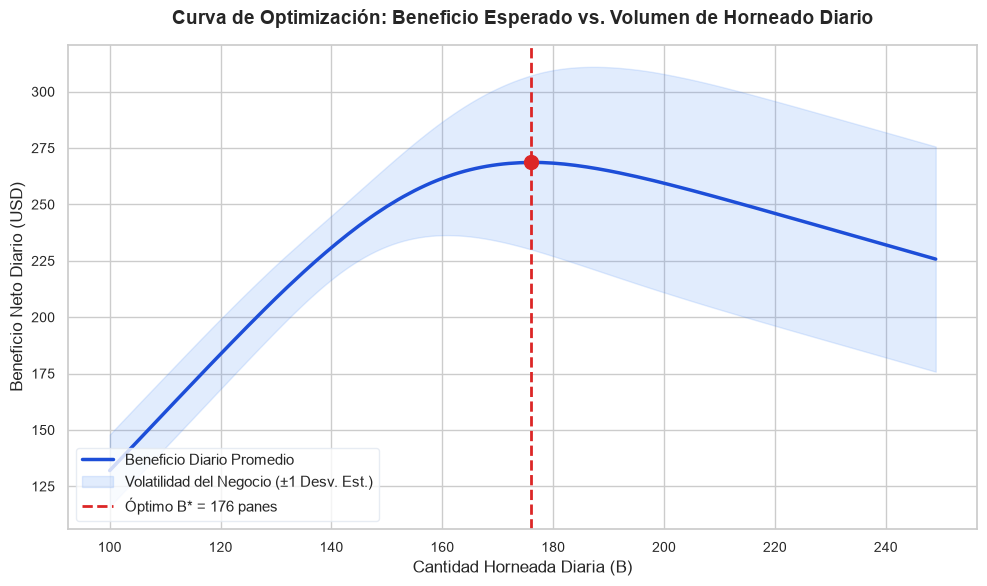

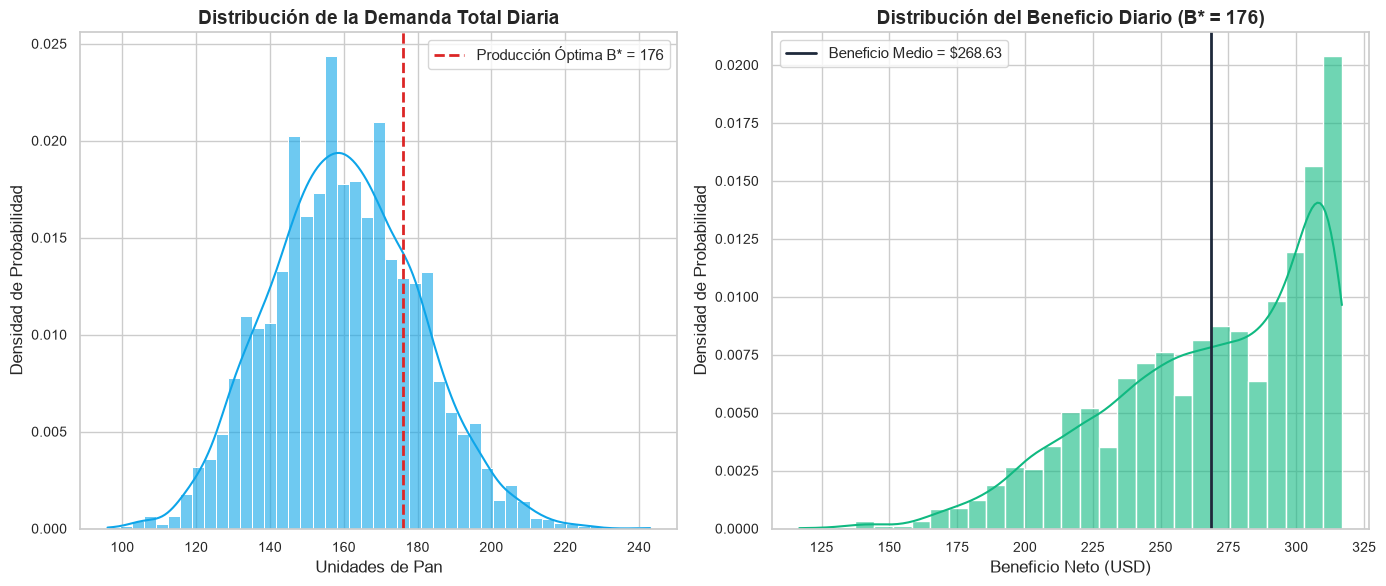

In [ ]:
# Gráfico 1: Beneficio Esperado vs. Cantidad Horneada
plt.figure(figsize=(10, 6))
plt.plot(rango_B, beneficios_promedio, color='#1d4ed8', linewidth=2.5, label='Beneficio Diario Promedio')

# Sombreado de la volatilidad (± 1 desviación estándar)
plt.fill_between(
    rango_B, 
    beneficios_promedio - beneficios_std, 
    beneficios_promedio + beneficios_std, 
    color='#3b82f6', 
    alpha=0.15, 
    label='Volatilidad del Negocio (±1 Desv. Est.)'
)

# Marcar el óptimo
plt.axvline(x=B_optimo, color='#dc2626', linestyle='--', linewidth=2, 
            label=f'Óptimo B* = {B_optimo} panes')
plt.scatter(B_optimo, max_beneficio, color='#dc2626', s=100, zorder=5)

plt.title('Curva de Optimización: Beneficio Esperado vs. Volumen de Horneado Diario', fontweight='bold', pad=15)
plt.xlabel('Cantidad Horneada Diaria (B)', fontsize=12)
plt.ylabel('Beneficio Neto Diario (USD)', fontsize=12)
plt.legend(loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.tight_layout()
plt.show()

# Gráfico 2: Distribución de Demanda y Beneficios de la Política Óptima
v_frescas_opt = np.minimum(demanda_diaria, B_optimo)
excedentes_opt = np.maximum(0, B_optimo - demanda_diaria)
escasez_opt = np.maximum(0, demanda_diaria - B_optimo)
beneficios_opt = (v_frescas_opt * PRECIO_VENTA) + (excedentes_opt * PRECIO_LIQ) - (B_optimo * COSTO_PROD) - (escasez_opt * COSTO_ESC)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de Demanda
sns.histplot(demanda_diaria, kde=True, ax=axes[0], color='#0ea5e9', stat='density', alpha=0.6)
axes[0].axvline(x=B_optimo, color='#dc2626', linestyle='--', linewidth=2, label=f'Producción Óptima B* = {B_optimo}')
axes[0].set_title('Distribución de la Demanda Total Diaria', fontweight='bold')
axes[0].set_xlabel('Unidades de Pan')
axes[0].set_ylabel('Densidad de Probabilidad')
axes[0].legend(frameon=True)

# Histograma de Beneficio Neto
sns.histplot(beneficios_opt, kde=True, ax=axes[1], color='#10b981', stat='density', alpha=0.6)
axes[1].axvline(x=max_beneficio, color='#1e293b', linestyle='-', linewidth=2, label=f'Beneficio Medio = ${max_beneficio:.2f}')
axes[1].set_title(f'Distribución del Beneficio Diario (B* = {B_optimo})', fontweight='bold')
axes[1].set_xlabel('Beneficio Neto (USD)')
axes[1].set_ylabel('Densidad de Probabilidad')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()



### Análisis y Conclusiones del Caso A
* La demanda de panes promedio es de aproximadamente **160 panes** diarios. Sin embargo, el volumen óptimo a hornear es de **166 panes**.
* **¿Por qué el óptimo es mayor que la demanda promedio?** Esto se debe a la estructura de costos asimétrica: el costo de oportunidad/insatisfacción de escasez ($0.80$ de costo por faltante más los $1.80$ de margen neto perdido, sumando en total $2.60$ de pérdida neta real) es significativamente mayor que la pérdida neta por producir un pan sobrante que se liquida ($1.20 - 0.50 = 0.70$ de pérdida neta por merma). Debido a esta asimetría, el método de Montecarlo sugiere "sesgarse" hacia el sobreabastecimiento prudente.
* El área sombreada en el primer gráfico muestra que la variabilidad diaria del beneficio neto es alta (entre $200 y $300 diarios aproximadamente), lo cual es normal dada la fluctuación tanto de clientes como de la cantidad individual que compra cada uno.

